# Regresión logística: ¿qué sistema operativo usa el visitante?

**Clase 4 – Aprendizaje Supervisado – Actividad 2**
**Alumna:** Mónica Frías

El objetivo es predecir el sistema operativo de un usuario que visita un sitio web a partir de cuatro características tomadas de Google Analytics:

| Columna | Descripción |
|---|---|
| `duracion` | Duración de la visita en segundos |
| `paginas` | Cantidad de páginas vistas durante la sesión |
| `acciones` | Cantidad de acciones del usuario (clicks, scroll, checkboxes, sliders, etc.) |
| `valor` | Suma del valor de las acciones |
| `clase` | Sistema operativo: **0 = Windows**, **1 = Macintosh**, **2 = Linux** |

Como la salida es discreta (tres categorías), se trata de un problema de **clasificación**, y usaremos **regresión logística** multiclase.

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

## 2. Preparación y organización de los datos

El dataset está guardado en la carpeta `datos` del repositorio, por eso la ruta sube un nivel (`..`) desde la carpeta `notebooks`.

In [2]:
df = pd.read_csv('../Datos/usuarios_win_mac_lin.csv')
df.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


In [3]:
print('Filas y columnas:', df.shape)
df.info()

Filas y columnas: (170, 5)
<class 'pandas.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB


In [4]:
# Valores faltantes por columna
df.isnull().sum()

duracion    0
paginas     0
acciones    0
valor       0
clase       0
dtype: int64

In [5]:
# Filas duplicadas
print('Filas duplicadas:', df.duplicated().sum())

Filas duplicadas: 16


No hay valores faltantes. Aparecen algunas filas duplicadas, pero las conservamos: es razonable que dos visitas distintas tengan exactamente los mismos valores (por ejemplo, 1 página vista con 1 acción), así que no parecen errores de carga.

Agregamos una columna con el nombre del sistema operativo, solo para que los gráficos y tablas sean más fáciles de leer (el modelo trabaja con la columna numérica `clase`).

In [6]:
nombres_so = {0: 'Windows', 1: 'Macintosh', 2: 'Linux'}
df['sistema_operativo'] = df['clase'].map(nombres_so)
df.head()

,duracion,paginas,acciones,valor,clase,sistema_operativo
0,7.0,2,4,8,2,Linux
1,21.0,2,6,6,2,Linux
2,57.0,2,4,4,2,Linux
3,101.0,3,6,12,2,Linux
4,109.0,2,6,12,2,Linux


## 3. Exploración de los datos (AED)

In [7]:
df.describe()

,duracion,paginas,acciones,valor,clase
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,111.075729,2.041176,8.723529,32.676471,0.752941
std,202.453200,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,11.000000,1.000000,3.000000,8.000000,0.000000
50%,13.000000,2.000000,6.000000,20.000000,0.000000
75%,108.000000,2.000000,10.000000,36.000000,2.000000
max,898.000000,9.000000,63.000000,378.000000,2.000000


In [8]:
# ¿Cuántos usuarios hay de cada sistema operativo?
df['sistema_operativo'].value_counts()

sistema_operativo
Windows      86
Linux        44
Macintosh    40
Name: count, dtype: int64

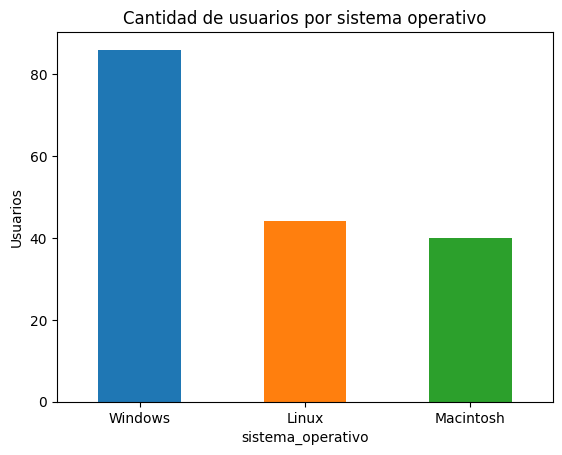

In [9]:
df['sistema_operativo'].value_counts().plot(kind='bar', color=['tab:blue', 'tab:orange', 'tab:green'])
plt.title('Cantidad de usuarios por sistema operativo')
plt.ylabel('Usuarios')
plt.xticks(rotation=0)
plt.show()

Las clases no están balanceadas: hay más usuarios de un sistema que de otros. Lo tenemos en cuenta al dividir los datos (usamos `stratify`) y al leer las métricas.

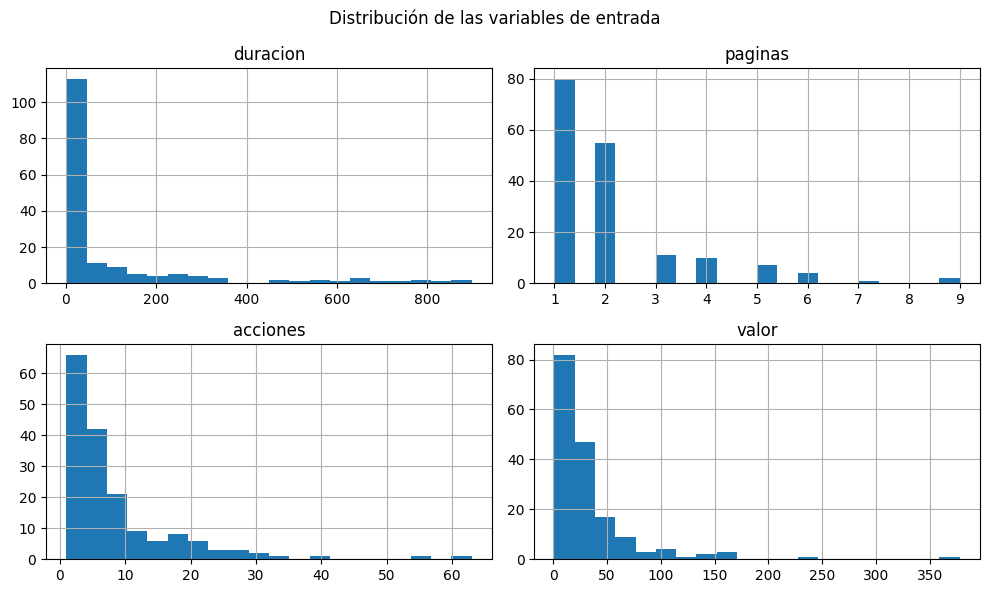

In [10]:
variables = ['duracion', 'paginas', 'acciones', 'valor']

# Histogramas de cada variable
df[variables].hist(bins=20, figsize=(10, 6))
plt.suptitle('Distribución de las variables de entrada')
plt.tight_layout()
plt.show()

In [11]:
# Promedio de cada variable según el sistema operativo
df.groupby('sistema_operativo')[variables].mean().round(2)

,duracion,paginas,acciones,valor
sistema_operativo,,,,
Linux,132.65,1.95,4.34,6.52
Macintosh,156.23,1.95,7.65,38.88
Windows,79.03,2.13,11.47,43.17


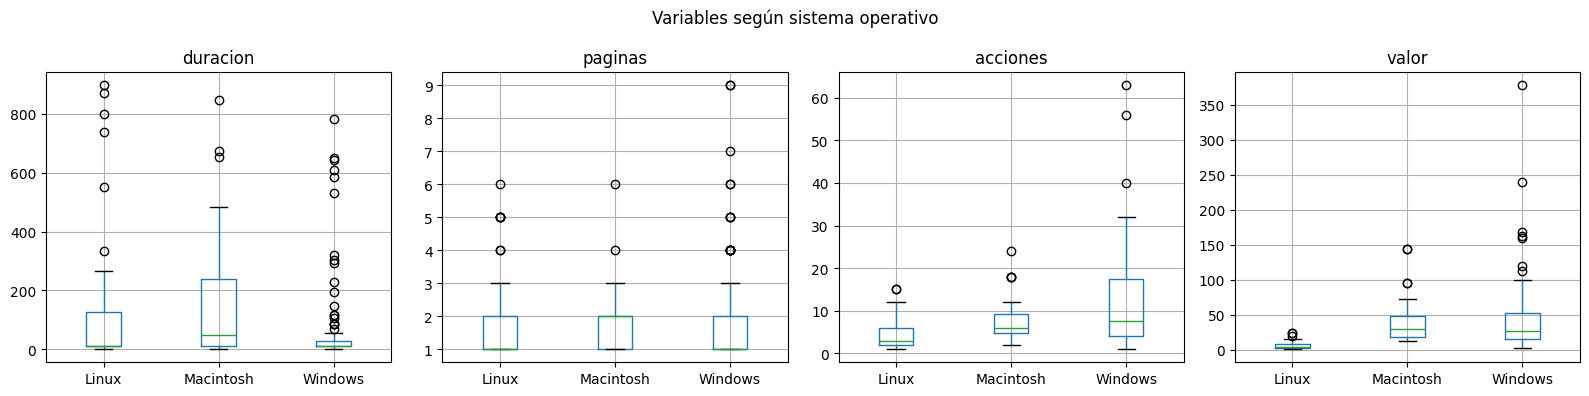

In [12]:
# Diagramas de caja por sistema operativo: permiten ver diferencias entre grupos y valores atípicos
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, var in zip(axes, variables):
    df.boxplot(column=var, by='sistema_operativo', ax=ax)
    ax.set_title(var)
    ax.set_xlabel('')
plt.suptitle('Variables según sistema operativo')
plt.tight_layout()
plt.show()

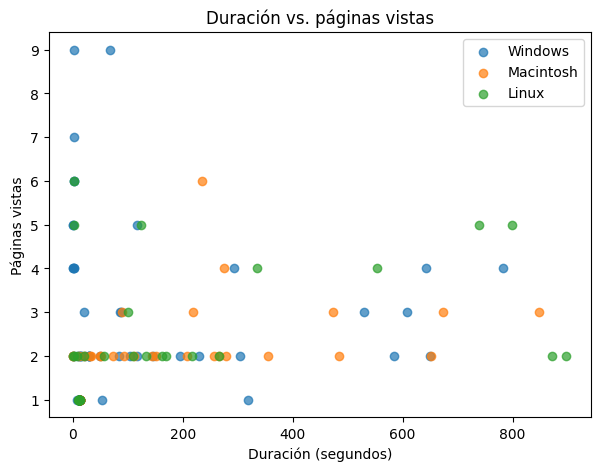

In [13]:
# Dispersión de dos variables, coloreando cada punto según su clase
colores = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green'}
plt.figure(figsize=(7, 5))
for clase, nombre in nombres_so.items():
    sub = df[df['clase'] == clase]
    plt.scatter(sub['duracion'], sub['paginas'], c=colores[clase], label=nombre, alpha=0.7)
plt.xlabel('Duración (segundos)')
plt.ylabel('Páginas vistas')
plt.title('Duración vs. páginas vistas')
plt.legend()
plt.show()

In [14]:
# Correlación entre las variables
df[variables + ['clase']].corr().round(2)

,duracion,paginas,acciones,valor,clase
duracion,1.00,0.28,0.16,0.09,0.13
paginas,0.28,1.00,0.72,0.58,-0.05
acciones,0.16,0.72,1.00,0.86,-0.33
valor,0.09,0.58,0.86,1.00,-0.32
clase,0.13,-0.05,-0.33,-0.32,1.00


## 4. Modelado

### 4.1 Separación en variables de entrada (X) y salida (y)

In [15]:
X = df[variables].values
y = df['clase'].values
print('X:', X.shape, ' y:', y.shape)

X: (170, 4)  y: (170,)


### 4.2 Conjuntos de entrenamiento y prueba

Separamos el 80 % para entrenar y el 20 % para probar. `stratify=y` mantiene la misma proporción de cada sistema operativo en ambos conjuntos, y `random_state` hace que el resultado sea reproducible.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Entrenamiento:', X_train.shape[0], 'muestras')
print('Prueba:       ', X_test.shape[0], 'muestras')

Entrenamiento: 136 muestras
Prueba:        34 muestras


### 4.3 Entrenamiento del modelo

Las variables tienen escalas muy distintas (segundos vs. cantidad de páginas), así que primero las estandarizamos con `StandardScaler` y después aplicamos `LogisticRegression`. Los unimos en un *pipeline* para que el escalado se aprenda solo con los datos de entrenamiento.

In [17]:
modelo = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
modelo.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

## 5. Evaluación del modelo

In [18]:
pred_train = modelo.predict(X_train)
pred_test = modelo.predict(X_test)

print('Exactitud (accuracy) en entrenamiento:', round(accuracy_score(y_train, pred_train), 3))
print('Exactitud (accuracy) en prueba:       ', round(accuracy_score(y_test, pred_test), 3))

Exactitud (accuracy) en entrenamiento: 0.676
Exactitud (accuracy) en prueba:        0.706


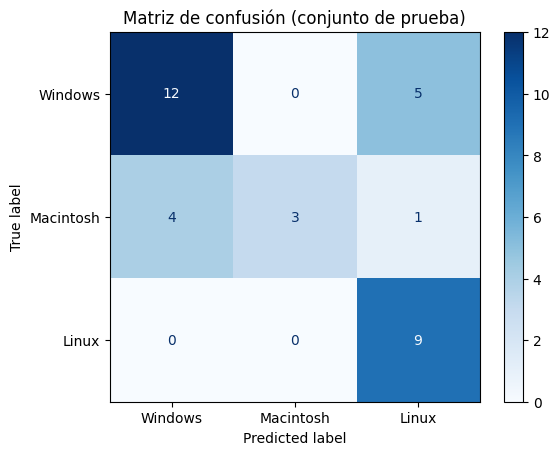

In [19]:
# Matriz de confusión: filas = clase real, columnas = clase predicha
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_test, display_labels=list(nombres_so.values()), cmap='Blues')
plt.title('Matriz de confusión (conjunto de prueba)')
plt.show()

In [20]:
print(classification_report(y_test, pred_test, target_names=list(nombres_so.values()), zero_division=0))

              precision    recall  f1-score   support

     Windows       0.75      0.71      0.73        17
   Macintosh       1.00      0.38      0.55         8
       Linux       0.60      1.00      0.75         9

    accuracy                           0.71        34
   macro avg       0.78      0.69      0.67        34
weighted avg       0.77      0.71      0.69        34



- **Precision:** de los que el modelo dijo que eran de una clase, qué proporción realmente lo era.
- **Recall:** de los que realmente eran de una clase, qué proporción detectó el modelo.
- **F1-score:** combina precision y recall en un solo número.

### 5.1 Validación cruzada

Como el dataset es chico, el resultado puede depender de cómo quedó la división. Con validación cruzada (5 particiones) obtenemos una estimación más estable.

In [21]:
scores = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
                         X, y, cv=5, scoring='accuracy')
print('Accuracy en cada partición:', scores.round(3))
print('Accuracy promedio:', round(scores.mean(), 3), '±', round(scores.std(), 3))

Accuracy en cada partición: [0.647 0.588 0.706 0.618 0.676]
Accuracy promedio: 0.647 ± 0.042


## 6. Predicción para nuevos usuarios

Probamos el modelo con usuarios inventados, que no estaban en el dataset.

In [22]:
nuevos = pd.DataFrame({
    'duracion': [10, 300, 60],
    'paginas':  [3, 1, 2],
    'acciones': [5, 20, 10],
    'valor':    [9, 30, 12],
})

pred_nuevos = modelo.predict(nuevos[variables].values)
prob_nuevos = modelo.predict_proba(nuevos[variables].values)

nuevos['prediccion'] = [nombres_so[p] for p in pred_nuevos]
for i, nombre in nombres_so.items():
    nuevos['prob_' + nombre] = prob_nuevos[:, i].round(2)
nuevos

,duracion,paginas,acciones,valor,prediccion,prob_Windows,prob_Macintosh,prob_Linux
0,10,3,5,9,Linux,0.27,0.14,0.59
1,300,1,20,30,Windows,0.92,0.06,0.02
2,60,2,10,12,Windows,0.59,0.12,0.30


## 7. Conclusiones

- **Exploración:** el dataset tiene 170 visitas sin valores faltantes. Las clases están desbalanceadas: Windows es la mayoría (86 usuarios), seguido por Linux (44) y Macintosh (40). Las variables que más diferencian a los grupos son `acciones` y `valor`: los usuarios de Linux realizan pocas acciones y de poco valor, mientras que los de Windows son los que más acciones realizan. Estas dos variables están muy correlacionadas entre sí. La `duracion` tiene mucha dispersión y valores atípicos (hasta casi 900 segundos).
- **Resultado del modelo:** la regresión logística alcanzó una exactitud de alrededor del 70 % en el conjunto de prueba, y la validación cruzada da un promedio cercano al 65 %. Si siempre predijéramos la clase más frecuente (Windows) acertaríamos un 51 %, así que el modelo aprende algo útil de los datos, aunque no es muy preciso.
- **Matriz de confusión:** el modelo reconoce muy bien a los usuarios de Linux, pero le cuesta identificar a los de Macintosh, que muchas veces los clasifica como otra clase. Tiene sentido, porque en los gráficos los valores de Macintosh se superponen bastante con los de Windows y Linux.
- **Limitaciones:** el dataset es chico, las clases están desbalanceadas y las cuatro variables no alcanzan para separar bien los tres sistemas operativos. Con más datos, más variables (por ejemplo, navegador o resolución de pantalla) o modelos no lineales, la predicción probablemente mejoraría.